In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mcsolve, mesolve, sigmam, sigmax
import pandas as pd
import lmfit
import corner
import emcee
from pylab import *
ion()

%matplotlib inline

In [3]:
#SET UP PARAMETERS
# number of modes
N = 2
# Destroy operator
a = destroy(N)
# oscillator Hamiltonian
H = a.dag() * a
# Initial excited (1) state
psi0 = basis(N, 1)
#dissipative terms
gamma_relax=1.0
T_1= 1/gamma_relax
k=0.5
#collapse operator
c_ops = []
c_ops.append(np.sqrt(k) * sigmam()) #c1= sqrt(kappa)*signam_- ------excitation
c_ops.append(np.sqrt(gamma_relax)*a) #c2= sqrt(kappa)*a -----decay

In [4]:
#Analytical solution for real-time tracking of states

#Generate trajectories
log_number_of_traj_min=np.log(100)
log_number_of_traj_max=np.log(10000)
steps=40
ntraj_plot_lin=np.linspace(log_number_of_traj_min,log_number_of_traj_max, steps)
ntraj_plot=np.round(np.exp(ntraj_plot_lin)).astype(int)

#Set up the total time of tracking each trajectory and number of samples in that timeframe
t_final=5
timeframe_samples=50
tlist = np.linspace(0, t_final, timeframe_samples)

In [5]:
#Monte carlo solver
### Simulate -and save- different decays with multiple trajectories

mc=[]
for i in ntraj_plot:
    print(i)
    mc.append(mcsolve(H, psi0, tlist, c_ops, [a.dag() * a], i))

100


10.0%. Run time:   0.11s. Est. time left: 00:00:00:01
20.0%. Run time:   0.12s. Est. time left: 00:00:00:00
30.0%. Run time:   0.13s. Est. time left: 00:00:00:00
40.0%. Run time:   0.13s. Est. time left: 00:00:00:00
50.0%. Run time:   0.14s. Est. time left: 00:00:00:00
60.0%. Run time:   0.14s. Est. time left: 00:00:00:00
70.0%. Run time:   0.15s. Est. time left: 00:00:00:00
80.0%. Run time:   0.15s. Est. time left: 00:00:00:00
90.0%. Run time:   0.15s. Est. time left: 00:00:00:00
100.0%. Run time:   0.15s. Est. time left: 00:00:00:00
Total run time:   0.16s
113
10.6%. Run time:   0.09s. Est. time left: 00:00:00:00
20.4%. Run time:   0.10s. Est. time left: 00:00:00:00
30.1%. Run time:   0.10s. Est. time left: 00:00:00:00
40.7%. Run time:   0.11s. Est. time left: 00:00:00:00
50.4%. Run time:   0.12s. Est. time left: 00:00:00:00
60.2%. Run time:   0.12s. Est. time left: 00:00:00:00
70.8%. Run time:   0.13s. Est. time left: 00:00:00:00
80.5%. Run time:   0.13s. Est. time left: 00:00:00:00

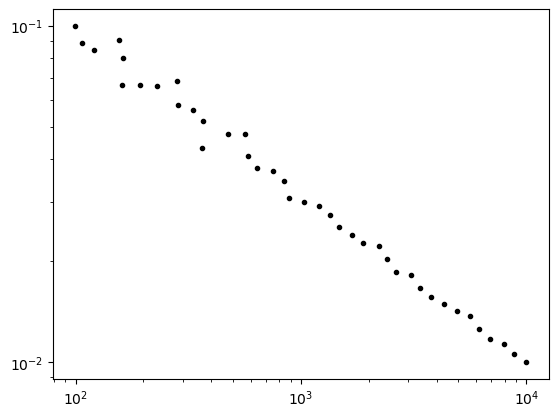

In [6]:
T_tot = T_1* ntraj_plot

for i in range(len(ntraj_plot)):
    
    #Extract first decay and coumpute T1    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc[i].col_times]
    T1= np.mean(first_elements)
    T_tot = T1* ntraj_plot
    #Plot numerical simulation for RTT
    plt.loglog(T_tot[i],np.sqrt(T1**3 /T_tot[i]),'.',color='black')

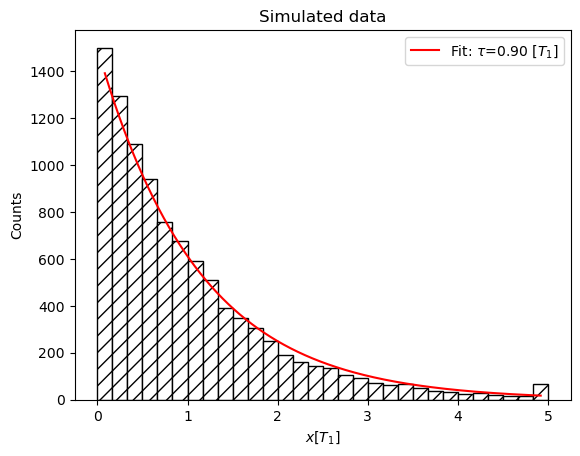

Fitted parameter: b = 0.8955707591429664


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Define the exponential function to fit (normalized to the maximum count)
def exponential_func(x, b):
    return np.exp(-b * x)

# Plot the histogram with diagonal lines inside the bars using counts
counts, bin_edges, _ = plt.hist(first_elements, bins=30, density=False, alpha=1.0, edgecolor='black', 
                                hatch='//', color='white')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit the exponential function to the histogram data
popt, pcov = curve_fit(exponential_func, bin_centers, counts/max(counts), p0=[1])

# Plot the fitted curve (scaled back to match the histogram counts)
x_fit = np.linspace(min(bin_centers), max(bin_centers), 1000)
y_fit = exponential_func(x_fit, *popt) * max(counts)

plt.plot(x_fit, y_fit, 'r-', label=f'Fit: $\\tau$={popt[0]:.2f} $[T_1]$')
plt.xlabel('$x[T_1]$')
plt.ylabel('Counts')
plt.legend()
plt.title('Simulated data')
plt.savefig("histogram.pdf",bbox_inches='tight')
plt.show()

# Print the fitted parameter
print(f"Fitted parameter: b = {popt[0]}")


In [9]:
from scipy.optimize import fsolve
import numpy as np

# Set up parameters for all other techniques that require both Active reset (AR) and Passive reset (PR)
t_wait = 10 * T_1
t_reset = 0.01 * T_1

In [10]:
### 1-SHOT SOLVER
#numerical solver to find the optimal sampling point (x_opt as) a function of gamma

# Define the equation d_gamma=0 as a function
def equation(x, gamma, t):
    term1 = (gamma * np.sqrt((t + x) / x**2) * np.exp(gamma * x)) / (2*(np.sqrt(np.exp(gamma * x) - 1)))
    term2 = (x**2 * np.sqrt((t + x) / x**2) * ((1 / (2 * x**2)) - (t + x) / x**3) * np.sqrt(np.exp(gamma * x) - 1)) / ((t + x))
    return (term1 + term2)

# Specify the value of gamma (we use the theoretical value of gamma_relax)
gamma_value = gamma_relax

# Choose an initial guess for the solution
initial_guess = 1 / gamma_value

# Solve the equation numerically 
x_opt_wait_1shot = fsolve(equation, initial_guess, args=(gamma_value, t_wait))
x_opt_reset_1shot = fsolve(equation, initial_guess, args=(gamma_value, t_reset))

##Return sigma_gamma, given the optimal sampling point. Theory in onennote
def d_gamma(x, gamma, t, T):
    return np.sqrt((x+t)/(x*x))*np.sqrt(np.exp(gamma*x)-1)/np.sqrt(T)

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/3218082012.py:6: RuntimeWarning: invalid value encountered in sqrt
  term1 = (gamma * np.sqrt((t + x) / x**2) * np.exp(gamma * x)) / (2*(np.sqrt(np.exp(gamma * x) - 1)))
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/3218082012.py:7: RuntimeWarning: invalid value encountered in sqrt
  term2 = (x**2 * np.sqrt((t + x) / x**2) * ((1 / (2 * x**2)) - (t + x) / x**3) * np.sqrt(np.exp(gamma * x) - 1)) / ((t + x))
/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [11]:
### 1-SHOT SIMULATION
#Simulation fitting an exp curve at the optimal point given by the previous analysis
N_experiments= 150

##SET up fitting function
def exponential_numerical(t_wait,T_1):
    return np.exp(-t_wait/T_1)

#Build a function to simulate the single shots that averaged will give the point on the curve (and the variance)
from scipy.optimize import curve_fit

def simulate_1point(T_tot,t_samp,t_w,T_1):
    #instead of working with samples/trajectories, I round up them, given a total time
    
    n_samp= np.round(T_tot/(t_samp+t_w)).astype(int)
    # Check if n_samp is zero
    if n_samp == 0:
        n_samp = 1  # Set n_samp to 1 if it is zero
    
    B_optimal=[]
    for N in arange(N_experiments):
        #create samples 
        samples=np.random.choice([0,1],n_samp,p=[1-exponential_numerical(t_samp,T_1),exponential_numerical(t_samp,T_1)])
        f=np.mean(samples)
        f_var=np.sum((f-samples)**2/(n_samp-1))
        f_dev=np.sqrt(f_var)/np.sqrt(n_samp)
        
        #fit the curve 
        #params, covariance = curve_fit(exponential_numerical, np.array([t_samp]), np.array([f]),sigma=np.array([f_dev]),absolute_sigma=True)
        #sigma_gamma=np.sqrt(covariance)
        #sigma_T1=sigma_gamma[0]
        #return f,f_dev,sigma_T1[0]

        #Instead of fit, substitute with solver for T1 (cannot invert eqaution) - qs every inversion gives just a T1, we have to repeat the experiment N times
        x = t_samp  # Example x values: x0, x1, x2
        y = np.array(f)  # Example y values: y0, y1, y2

        # Define the inverse function 
        def invert(x, y):
            return - np.log(y)/x

        # Optimize B
        B_optimal.append(invert(x, y))

    # Function to perform bootstrap resampling and calculate standard deviation
    def bootstrap_std(data, num_samples=10000):
        n = len(data)
        bootstrapped_stds = []
        for _ in range(num_samples):
            sample = np.random.choice(data, size=n, replace=True)
            sample_std = np.std(sample)
            bootstrapped_stds.append(sample_std)
        
        # Calculating the standard deviation of the standard deviations
        std_of_std = np.std(bootstrapped_stds)
        return std_of_std    
    
    return np.std(B_optimal), bootstrap_std(B_optimal)

In [12]:
#### 1- POINT SIMULATION RUN
T_tot = T_1* ntraj_plot

sigmas_reset_1p=[]
sigmas_wait_1p=[]
sigmasigmas_reset_1p=[]
sigmasigmas_wait_1p=[]
#Running experiment 
for T in T_tot:
    sigmas_reset_1p.append(simulate_1point(T,x_opt_reset_1shot[0]*T_1,t_reset,T_1)[0])
    sigmas_wait_1p.append(simulate_1point(T,x_opt_wait_1shot[0]*T_1,t_wait,T_1)[0])

    sigmasigmas_reset_1p.append(simulate_1point(T,x_opt_reset_1shot[0]*T_1,t_reset,T_1)[1])
    sigmasigmas_wait_1p.append(simulate_1point(T,x_opt_wait_1shot[0]*T_1,t_wait,T_1)[1])

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/217909858.py:40: RuntimeWarning: divide by zero encountered in log
  return - np.log(y)/x
/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [13]:
##3 POINTS SOLVER - find numerical solution (FIND THE OPTIMAL POINT GIEVN T WAIT/RESET)
import scipy
import scipy.optimize
import sympy as sp

y = sp.Array(sp.symbols("y:3"))
x = sp.Array(sp.symbols("x:3"))
b = sp.Function("b")(y[0], y[1], y[2])

#Build equation, differntiate respective to each variable (y) and solve to mget db/dy
eq = (sp.exp(-x[0] * b) - sp.exp(-x[1] * b)) / (
    sp.exp(-x[1] * b) - sp.exp(-x[2] * b)
) - (y[0] - y[1]) / (y[1] - y[2])

deriv = sp.diff(eq, y[0])

db_dy0 = sp.simplify(
    sp.solve(
        sp.diff(
            eq,
            y[0],
        ),
        sp.diff(b, y[0]),
    )[0]
)

#Set Parameters
bb=gamma_relax # Setting T1

db_dy0_in_x = sp.simplify(
    db_dy0.subs([(b, bb)] + list((y[i], sp.exp(-bb*x[i])) for i in range(3)))
)

xp = sp.Array(sp.symbols("xp:3"))
db_dy_in_x = [0, 0, 0]

db_dy_in_x[0] = db_dy0_in_x
db_dy_in_x[1] = db_dy0_in_x.subs([(x[2], xp[0]), (x[1], xp[2]), (x[0], xp[1])]).subs(
    [(xp[0], x[0]), (xp[1], x[1]), (xp[2], x[2])]
)
db_dy_in_x[2] = db_dy0_in_x.subs([(x[2], xp[1]), (x[1], xp[0]), (x[0], xp[2])]).subs(
    [(xp[0], x[0]), (xp[1], x[1]), (xp[2], x[2])]
)

#This returns the optimal points given the wait/reset time
def p3_bests_solver(tt):    

    def db(x_values):

        dy = [(sp.exp(-bb*x[i]) - sp.exp(-2 * bb*x[i])) * (sum(x) + 3 * tt) for i in range(3)] # Have to include N here (convert to total time)
        result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3))).evalf(
            subs={x[i]: x_values[i] for i in range(3)}
        )
        # print(x_values, result)

        return result


    p3_opt=scipy.optimize.minimize(db, [0.01, 0.3, 2],  bounds=[(0, 20), (0.01, 20), (0.02, 20)])['x'] #3 optimal points
    return p3_opt

In [ ]:
#3p theory solution
T_tot = T_1* ntraj_plot
p3theory=[]

#This returns the data for the theoretical value of sigma_t1 for the 3p solution
for tt in [t_reset,t_wait]:
    p3_opt=p3_bests_solver(tt)
    dy = [(sp.exp(-bb*x[i]) - sp.exp(-2 *bb* x[i])) * (sum(x) + 3 * tt) for i in range(3)]
    sigma_3p_gamma = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3)))
    res=[]
    for T in T_tot:
        res.append(sigma_3p_gamma.evalf(subs={x[i]: p3_opt[i] for i in range(3)})/np.sqrt(T)/gamma_relax**2) #gamma_relax**2 to convert to T1
    p3theory.append(res)

In [57]:
### 3-SHOTs SIMULATION
#Simulation fitting an exp curve at the optimal point given by the previous analysis
from scipy.optimize import minimize

#Set up numer of experiments per point
N_exp=300 

##SET up generating function
def exponential_numerical(t_wait,T_1):
    return np.exp(-t_wait/T_1)

##SET up fitting function
def exponential_numerical_3p(t_wait,T_1, A, C):
    return A*np.exp(-t_wait/T_1)+C

#Build a function to simulate the single shots that averaged will give the point on the curve (and the variance)
from scipy.optimize import curve_fit

def simulate_3point(T_tot,t_samp,t_w,T_1):
    #instead of working with samples/trajectories, I round up them, given a total time
 # Check if one of the sampling point is zero
    #if t_samp[0] == 0:
        #t_samp[0] = 0.01  # Set n_samp to 1 if it is zero

    n_samp= np.round(T_tot/(np.sum(t_samp)+3*t_w)).astype(int)
    # Check if n_samp is zero
    if n_samp == 0:
        n_samp = 1  # Set n_samp to 1 if it is zero

    B_optimal=[]
    for N in arange(N_exp):

        #create samples (3 points)
        samples=[]
        f=[]
        f_var=[]
        f_dev=[]
        for i in range(3):
            samples.append(np.random.choice([0,1],n_samp,p=[1-exponential_numerical_3p(t_samp[i],T_1,1.,0.),exponential_numerical_3p(t_samp[i],T_1,1.,0.)]))
            f.append(np.mean(samples[i]))
            f_var.append(np.sum((f[i]-samples[i])**2/(n_samp-1)))
            f_dev.append(np.sqrt(f_var[i])/np.sqrt(n_samp))
        
        #Instead of fit, substitute with solver for T1 (cannot invert eqaution) - qs every inversion gives just a T1, we have to repeat the experiment N times
        x = t_samp  # Example x values: x0, x1, x2
        y = np.array(f)  # Example y values: y0, y1, y2

        # Define the objective function for the single data set
        def objective(B, x, y):
            # Left side of the equation
            left = (y[0] - y[1]) / (y[1] - y[2])
            
            # Right side of the equation
            right = (np.exp(-B * x[0]) - np.exp(-B * x[1])) / (np.exp(-B * x[1]) - np.exp(-B * x[2]))
            
            # Calculate the square of the difference to minimize
            difference = left - right
            return difference ** 2

        # Function to optimize B for the single data set
        def optimize_B(x, y):
            initial_guess = [5]  # Initial guess for B
            result = minimize(objective, initial_guess, args=(x, y))
            return result.x[0]

        # Optimize B
        B_optimal.append(optimize_B(x, y))

    # Function to perform bootstrap resampling and calculate standard deviation
    def bootstrap_std(data, num_samples=10000):
        n = len(data)
        bootstrapped_stds = []
        for _ in range(num_samples):
            sample = np.random.choice(data, size=n, replace=True)
            sample_std = np.std(sample)
            bootstrapped_stds.append(sample_std)
        
        # Calculating the standard deviation of the standard deviations
        std_of_std = np.std(bootstrapped_stds)
        return std_of_std    
    
    return np.std(B_optimal), bootstrap_std(B_optimal)
#### Use the function to get the optimal points for T_tot=...
simulate_3point(1000,p3_bests_solver(t_reset),t_reset,T_1)[0]

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/2520260576.py:51: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3))).evalf(


0.09887670874470264

In [58]:
### 3-SHOTs SIMULATION RUN --
T_tot = T_1* ntraj_plot
sigmas_reset_3p=[]
sigmas_wait_3p=[]
sigmasigmas_reset_3p=[]
sigmasigmas_wait_3p=[]

#Creating samples
for TT in T_tot:
    sigmas_reset_3p.append(simulate_3point(TT,p3_bests_solver(t_reset),t_reset,T_1)[0])
    sigmas_wait_3p.append(simulate_3point(TT,p3_bests_solver(t_wait),t_wait,T_1)[0])

    sigmasigmas_reset_3p.append(simulate_3point(TT,p3_bests_solver(t_reset),t_reset,T_1)[1])
    sigmasigmas_wait_3p.append(simulate_3point(TT,p3_bests_solver(t_wait),t_wait,T_1)[1])

/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/2520260576.py:51: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3))).evalf(
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/3855774761.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  left = (y[0] - y[1]) / (y[1] - y[2])
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/2520260576.py:51: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3))).evalf(
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_60998/3855774761.py:51: RuntimeWarning: divide by zero encountered in scalar divi

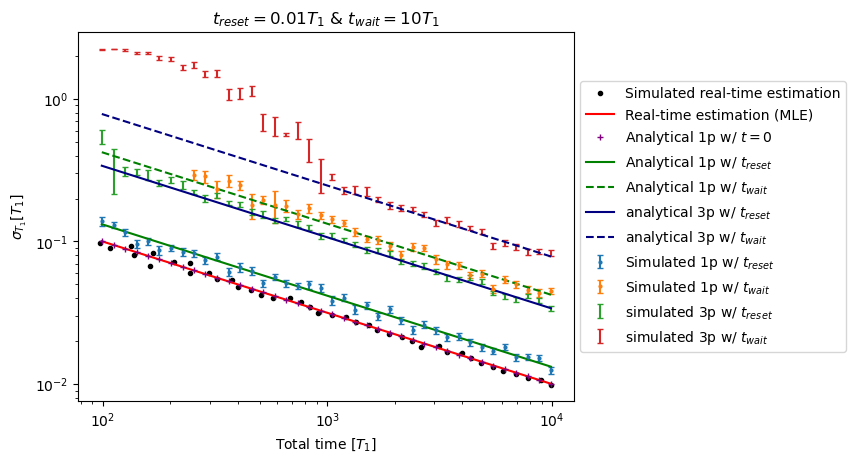

In [59]:
#Plot T1 vs total experimental time for real time tracking
T_tot = T_1* ntraj_plot
# Flag to add the label only once
label_added = False

for i in range(len(ntraj_plot)):
    
    #plot for real time tracking (RTT)
    #Extract first decay and coumpute T1    
    first_elements = [arr[0] if arr.size > 0 else t_final for arr in mc[i].col_times]
    T1= np.mean(first_elements)
    T_tot = T1* ntraj_plot
    #Plot numerical simulation for RTT
    #plt.loglog(T_tot[i],np.sqrt(T1**3 /T_tot[i]),'.',color='black')
    if not label_added:
        plt.loglog(T_tot[i], np.sqrt(T1**3 / T_tot[i]), '.', color='black', label='Simulated real-time estimation')
        label_added = True
    else:
        plt.loglog(T_tot[i], np.sqrt(T1**3 / T_tot[i]), '.', color='black')



#plot the simulated data for the 1 shot solution
plt.errorbar(T_tot,np.array(sigmas_reset_1p)/gamma_relax**2,yerr=np.array(sigmasigmas_reset_1p)/gamma_relax**2,markersize=2,capsize=2,linestyle="", label='Simulated 1p w/ $t_{reset}$', fmt='o')
plt.errorbar(T_tot,np.array(sigmas_wait_1p)/gamma_relax**2,yerr=np.array(sigmasigmas_wait_1p)/gamma_relax**2,markersize=2,capsize=2,linestyle="", label='Simulated 1p w/ $t_{wait}$', fmt='o')

#plot the simulated data for the 3 shot solution
plt.errorbar(T_tot,np.array(sigmas_reset_3p)/gamma_relax**2,yerr=np.array(sigmasigmas_reset_3p)/gamma_relax**2,capsize=2,linestyle="", label='simulated 3p w/ $t_{reset}$')
plt.errorbar(T_tot,np.array(sigmas_wait_3p)/gamma_relax**2,yerr=np.array(sigmasigmas_wait_3p)/gamma_relax**2,capsize=2,linestyle="", label='simulated 3p w/ $t_{wait}$')

#Plot theoretical solution for RTT
plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),color='red',markersize=1, label='Real-time estimation (MLE)')

# plot of the theoretical curve for fixed total experimental time T = N*x_0, which means instant active reset
plt.plot(T_tot, 1/gamma_relax**1.5/np.sqrt(T_tot),"+", color='purple',markersize=4, label='Analytical 1p w/ $t=0$')

#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_reset=1% of T1 (ACTIVE RESET BEST)
plt.plot(T_tot, d_gamma(x_opt_reset_1shot*T_1,gamma_relax,t_reset,T_tot)/gamma_relax**2 ,color='green',markersize=1, label='Analytical 1p w/ $t_{reset}$')
#plot of the theoretical (numerical x_opt) curve for multiple shots in one point, with t_wait=10*T1 (PASSIVE RESET)
plt.plot(T_tot, d_gamma(x_opt_wait_1shot*T_1,gamma_relax,t_wait,T_tot)/gamma_relax**2 ,color='green',linestyle='dashed',markersize=1, label='Analytical 1p w/ $t_{wait}$')

#Plot theoretical curve for 3 point solver
plt.loglog(T_tot,p3theory[0], color='navy',label='analytical 3p w/ $t_{reset}$')
plt.loglog(T_tot,p3theory[1], color='navy',linestyle='dashed',label='analytical 3p w/ $t_{wait}$')

plt.xlabel('Total time $[T_1]$')
plt.ylabel('$\sigma_{T_1} [T_1]$')
plt.title('$t_{reset}=0.01 T_1$ & $t_{wait}=10T_1$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#plt.ylim(0.0015,0.3)
plt.savefig("final3lines.pdf",bbox_inches='tight')
